# **Data Preparation & Exploration**

## Objectives
- Prepare and explore the Spotify dataset.
- Perform descriptive statistics and exploratory data analysis (EDA) to understand relationships between audio features and song popularity.

## Inputs
- Spotify dataset
- Python libraries: pandas, numpy, matplotlib

## Outputs
- Descriptive statistics summary
- Visualisations (histograms, scatter plots, correlation matrix)
- Insights used to guide hypothesis testing in the next notebook

## Additional Comments
- This notebook focuses on data understanding and exploration. Statistical testing and modelling are performed in the next notebook.


---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [75]:
import os
current_dir = os.getcwd()
current_dir

'/Users/priyanatt1'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [76]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [77]:
current_dir = os.getcwd()
current_dir

'/Users'

---

# Section 1 - Extract, Transform and Loading the data

In [78]:
import pandas as pd
import numpy as np

In [79]:
df = pd.read_csv("/Users/priyanatt1/Documents/VSC-projects/spotify-popularity-analysis/Data/raw/dataset.csv") 
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [80]:
df.shape
# Check how many rows and columns are in the dataset

(114000, 21)

In [81]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [82]:
df.info()
# Check for missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [83]:
df.duplicated().sum()
#check for duplicates

0

In [84]:
df = df.drop_duplicates()
#remove duplicates

In [85]:
df.duplicated().sum()
# Check for duplicates again to confirm they have been removed

0

In [86]:
df.isnull().sum()
# Check for missing values

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [87]:
df.dtypes
# Check data types of each column

Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

In [88]:
df = df[[
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "tempo",
    "valence"
]]
# The required columns for analysis

In [89]:
df_clean = df.copy()

df_clean.to_csv("spotify_clean.csv", index=False)

PermissionError: [Errno 13] Permission denied: 'spotify_clean.csv'

---

# Section 2 - Core Statistical Concepts

## Descriptive Statistics

Descriptive statistics are used to summarise and describe sections of a dataset. In this project, descriptive statistics are used to analyse Spotify track popularity and audio features.

#### Mean (μ)

<u>What is the mean?</u>

The mean is the average of a dataset and is calculated by summing all the values and dividing by the total number of observations in the sample. However, the mean can be affected by outliers, as unusually high or low values can make the mean higher or lower then it is.

<u>In the context of the dataset:</u>

Track popularity is measured on a scale from 0 to 100. The mean popularity helps show the overall average popularity of songs in the dataset. For example, we can calculate the average popularity of songs with higher energy levels and compare it to songs with lower energy levels to explore whether more energetic songs tend to be more popular.



#### Median

<u>What is the median?</u>

The median is the middle value of a dataset when the data is arranged in ascending order. If there is an even number of observations, the median is calculated by taking the average of the two middle values. The median is less affected by extreme values, which makes it useful when the data contains outliers.

<u>In the context of the dataset:</u>

If a small number of songs become extremely popular, such as viral tracks with very high popularity scores, they may increase the mean popularity significantly. In this case, the median popularity may better represent the typical popularity of songs in the dataset.



#### Variance (σ²) and Standard Deviation (σ)

<u>What is variance and standard deviation?</u>

Variance and standard deviation measure the spread or dispersion of values around the mean. Variance (σ²) measures the average squared difference between each value and the mean of the dataset. Standard deviation (σ) is the square root of variance and shows how far values typically vary from the mean in the same units as the data.

<u>In the context of the dataset:</u>

A high standard deviation in popularity would indicate that song popularity varies widely, meaning some songs are much more popular than others. A low standard deviation would suggest that most songs have similar popularity scores. Standard deviation can also be used when analysing tempo to understand how much variation exists in song tempo across the dataset. This helps support the analysis of tempo ranges associated with popular songs.



#### Percentiles and Quartiles

<u>What are percentiles and quartiles?</u>

Percentiles divide a dataset into equal parts and help show how values are distributed within the data. Quartiles are specific percentiles that divide the dataset into four equal sections. These include the first quartile (Q1) which represents the 25th percentile, the second quartile (Q2) which represents the 50th percentile and is the median, and the third quartile (Q3) which represents the 75th percentile.

The Interquartile Range (IQR) measures the spread of the middle 50% of the dataset and is calculated using the formula:

IQR = Q3 − Q1

The IQR is useful because it is less affected by extreme values and provides a clearer understanding of the spread of the data.

<u>In the context of the dataset:</u>

If the popularity scores for the middle 50% of songs fall between 40 and 70, this suggests that most tracks in the dataset have moderate popularity levels, while only a smaller proportion of tracks reach very high popularity scores. Percentiles can also help when analysing audio features such as energy and danceability, as they can show the range in which most popular songs fall. This helps support the analysis of how audio features relate to song popularity.

---

## Probability & Distributions

Probability measures how likely something is to happen. It ranges from 0 to 1, where 0 means the event cannot happen and 1 means the event will definitely happen.

#### Probability Basics

- P(event) ranges from 0 (impossible) to 1 (certain)
- P(A or B) = P(A) + P(B) − P(A and B) (addition rule)
- P(A and B) = P(A) × P(B|A) (multiplication rule for dependent events)
- In the context of the dataset: If 30% of songs in the dataset are explicit (P(explicit) = 0.30), then 70% are non-explicit (P(non-explicit) = 0.70).


#### Normal Distribution (Gaussian)

- A normal distribution is a bell-shaped and symmetrical distribution.
- It is defined by the mean (μ) and standard deviation (σ).
- About 68% of data falls within ±1σ of the mean.
- About 95% of data falls within ±2σ of the mean.
- About 99.7% of data falls within ±3σ of the mean (Empirical Rule).

- <u>In the context of the dataset:</u>
  If song popularity were normally distributed with a mean popularity of 60 and a standard deviation of 10, then around 68% of songs would have popularity scores between 50 and 70.


#### Skewness

- Right-skewed (positive skew): The tail of the distribution extends to the right, meaning the mean is greater than the median.
- Left-skewed (negative skew): The tail of the distribution extends to the left, meaning the mean is less than the median.
- Skewness helps show whether data is symmetrical or unevenly distributed.

- <u>In the context of the dataset:</u>  
  Song popularity may be right-skewed, because a small number of songs become extremely popular while most songs have moderate or low popularity scores.


#### Central Limit Theorem (CLT)

<u>What is the Central Limit Theorem?</u>

The Central Limit Theorem states that as the sample size increases, the distribution of the sample mean approaches a normal distribution regardless of the shape of the population distribution. This generally applies when the sample size is 30 or more observations.

<u>In the context of the dataset:</u>

Since the dataset contains a large number of songs, the Central Limit Theorem allows us to apply statistical tests, such as hypothesis testing, even if the original data is not perfectly normally distributed.


---

## Hypothesis Testing Framework

Hypothesis testing provides a structured way to make conclusions about data using statistical evidence. It helps determine whether relationships observed in the dataset are statistically significant or likely to have occurred by chance.



#### Null Hypothesis (H₀)

<u>What is the null hypothesis?</u>

The null hypothesis represents the default assumption that there is no relationship or no difference between variables. It is the statement that researchers attempt to test against using statistical analysis.

<u>In the context of the dataset:</u>

An example of a null hypothesis in this project is that audio features such as energy and danceability have no relationship with song popularity.



#### Alternative Hypothesis (H₁)

<u>What is the alternative hypothesis?</u>

The alternative hypothesis represents the claim that there is a relationship or difference between variables. It is the hypothesis that researchers aim to support using evidence from the data.

<u>In the context of the dataset:</u>

For example, the alternative hypothesis may suggest that songs with higher energy and danceability tend to have higher popularity scores.



#### P-Value

<u>What is a p-value?</u>

A p-value measures the probability of obtaining results at least as extreme as those observed, assuming that the null hypothesis is true.

- A small p-value (typically less than 0.05) suggests strong evidence against the null hypothesis.
- A large p-value suggests that there is not enough evidence to reject the null hypothesis.

<u>In the context of the dataset:</u>

The p-value will help determine whether relationships between variables such as energy, danceability, explicit content, and tempo with song popularity are statistically significant.



#### Significance Level (α)

<u>What is the significance level?</u>

The significance level represents the threshold used to decide whether the null hypothesis should be rejected. It is commonly set at α = 0.05.

If the p-value is less than the significance level, the null hypothesis is rejected. If the p-value is greater than or equal to the significance level, the null hypothesis cannot be rejected.

<u>In the context of the dataset:</u>

Using a significance level of 0.05 allows us to determine whether the observed relationships between song characteristics and popularity are statistically meaningful.



#### Confidence Intervals

<u>What are confidence intervals?</u>

A confidence interval provides a range of values that is likely to contain the true population parameter. A 95% confidence interval means that we are 95% confident that the true value lies within the calculated range.

<u>In the context of the dataset:</u>

Confidence intervals can be used to estimate the range in which the true relationship between audio features and song popularity may lie.

---

## Types of Statistical Tests Used in This Analysis

The following statistical tests are used to analyse relationships within the dataset and evaluate the project hypotheses.



#### Spearman Correlation

<u>What is Spearman correlation?</u>

Spearman correlation is a statistical test used to measure the strength and direction of the relationship between two variables. It is a non-parametric test, which means it does not assume that the data follows a normal distribution. Spearman correlation works by analysing the ranked values of the variables rather than the raw values.

The correlation coefficient ranges from -1 to 1.

- A value close to 1 indicates a strong positive relationship.
- A value close to -1 indicates a strong negative relationship.
- A value close to 0 indicates little or no relationship.

<u>In the context of the dataset:</u>

Spearman correlation can be used to examine the relationship between audio features such as energy and danceability with song popularity. This helps determine whether songs with higher energy or danceability tend to have higher popularity scores.



#### Welch’s t-test

<u>What is Welch’s t-test?</u>

Welch’s t-test is a statistical test used to compare the mean values of two independent groups. It is particularly useful when the groups may have unequal variances or different sample sizes. Unlike the standard Student’s t-test, Welch’s t-test does not assume that the two groups have equal variance, making it a more robust method for comparing group means.

<u>In the context of the dataset:</u>

Welch’s t-test can be used to compare the average popularity of songs with high acousticness and songs with low acousticness. This helps determine whether there is a statistically significant difference in popularity between songs that are more acoustic and those that are less acoustic.



#### Analysis of Variance (ANOVA)

<u>What is ANOVA?</u>

Analysis of Variance (ANOVA) is a statistical test used to compare the mean values of three or more groups. It helps determine whether there is a statistically significant difference between the groups being analysed.

<u>In the context of the dataset:</u>

ANOVA can be used to compare the average popularity of songs across different tempo ranges, such as slow, moderate, and fast songs. This helps determine whether songs with moderate tempo ranges tend to have higher popularity than songs with very slow or very fast tempos.

---

# Section 3 - Descriptive Stats + EDA

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [91]:
df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996
instrumentalness,114000.0,0.156050,0.309555,0.000,0.00000,0.000042,0.0490,1.000
liveness,114000.0,0.213553,0.190378,0.000,0.09800,0.132000,0.2730,1.000
tempo,114000.0,122.147837,29.978197,0.000,99.21875,122.017000,140.0710,243.372
valence,114000.0,0.474068,0.259261,0.000,0.26000,0.464000,0.6830,0.995


### Key Descriptive Statistics in the context of the dataset

- The Spotify dataset contains 114,000 songs with many audio features such as danceability, energy, acousticness, and tempo, as well as the popularity score of each song.

- The descriptive statistics show that the average popularity score is 33.24, with values ranging from 0 to 100, showing a wide variation in how popular songs are on Spotify. Many audio features such as danceability, energy, acousticness, and valence are scaled between 0 and 1, while tempo is measured in beats per minute.

- The average tempo is approximately 122.15 BPM, suggesting that most songs fall within a moderate tempo range. These statistics confirm that the dataset values appear reasonable and suitable for further analysis.

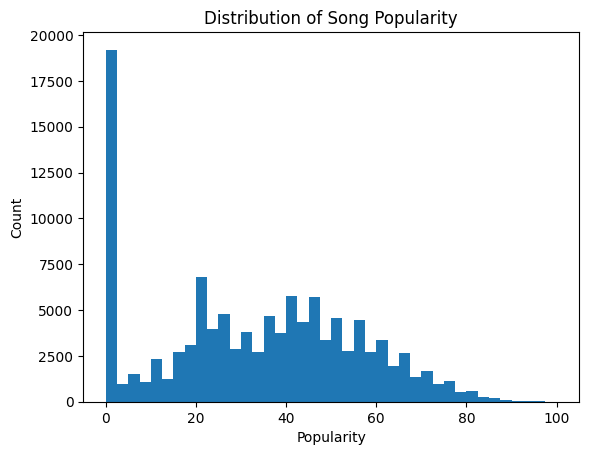

In [92]:
plt.figure()
plt.hist(df["popularity"], bins=40)
plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.show()

### Popularity Distribution in the context of the dataset

- The histogram shows that a large number of songs have very low popularity values, which is shown at the origin. This suggests that many songs in the dataset are not highly streamed.

- The distribution is spread across moderate popularity values, with fewer songs reaching very high popularity levels. 

- Overall, the distribution appears right-skewed meaning that only a smaller proportion of songs achieve very high popularity scores.

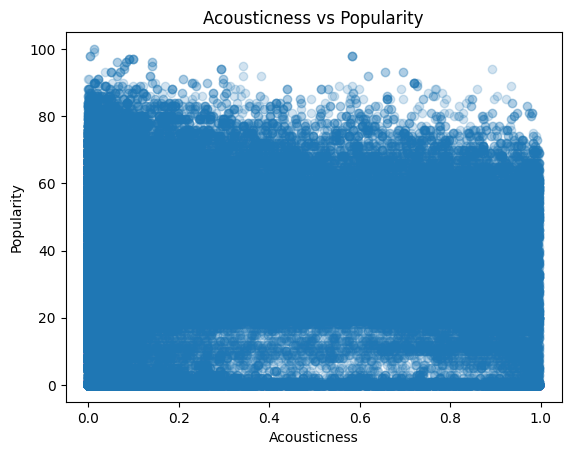

In [93]:
plt.figure()
plt.scatter(df["acousticness"], df["popularity"], alpha=0.2)
plt.title("Acousticness vs Popularity")
plt.xlabel("Acousticness")
plt.ylabel("Popularity")
plt.show()

### Acousticness vs Popularity in the context of the dataset

- There does not seem to be a clear relationship between acousticness and popularity. Songs with both low and high acousticness values appear across the entire popularity range suggesting that acousticness alone may not strongly influence how popular a song becomes.

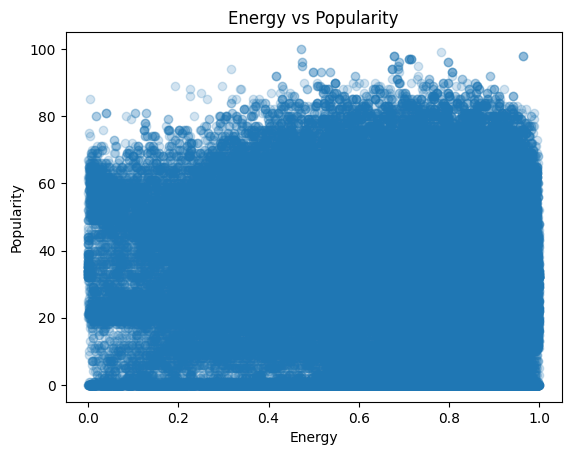

In [94]:
plt.figure()
plt.scatter(df["energy"], df["popularity"], alpha=0.2)
plt.title("Energy vs Popularity")
plt.xlabel("Energy")
plt.ylabel("Popularity")
plt.show()

### Energy vs Popularity in the context of the dataset

- There is no strong visual pattern suggesting that higher energy songs are consistently more popular. 

- The relationship between energy and popularity may be weak or influenced by other factors in the dataset

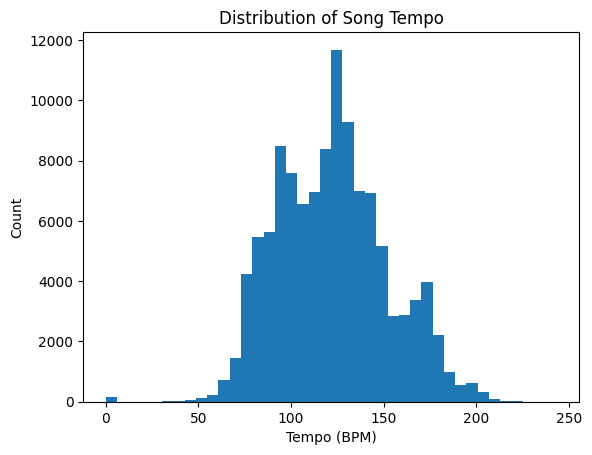

In [96]:
plt.figure()
plt.hist(df["tempo"], bins=40)
plt.title("Distribution of Song Tempo")
plt.xlabel("Tempo (BPM)")
plt.ylabel("Count")
plt.show()

### Tempo Distribution in the context of the dataset

- The histogram shows that most songs in the dataset have tempos around the 100–140 BPM range, with the average tempo being approximately 130 BPM.

- The distribution appears bell-shaped suggesting that moderate tempo songs are the most common, while very slow and very fast songs are not.

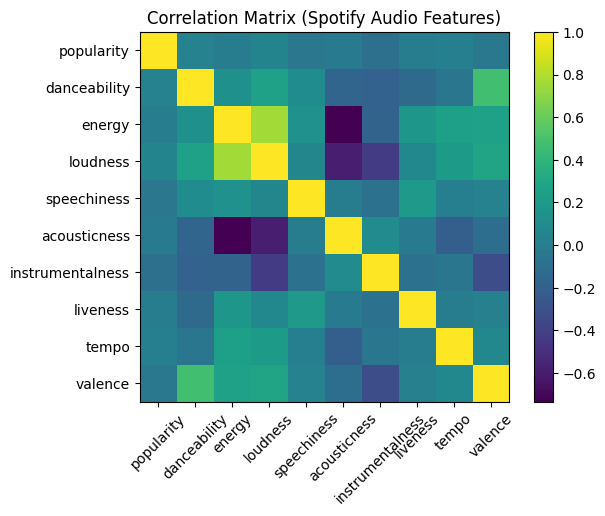

,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,tempo,valence
popularity,1.000000,0.035448,0.001056,0.050423,-0.044927,-0.025472,-0.095139,-0.005387,0.013205,-0.040534
danceability,0.035448,1.000000,0.134325,0.259077,0.108626,-0.171533,-0.185606,-0.131617,-0.050450,0.477341
energy,0.001056,0.134325,1.000000,0.761690,0.142509,-0.733906,-0.181879,0.184796,0.247851,0.258934
loudness,0.050423,0.259077,0.761690,1.000000,0.060826,-0.589803,-0.433477,0.076899,0.212446,0.279848
speechiness,-0.044927,0.108626,0.142509,0.060826,1.000000,-0.002186,-0.089616,0.205219,0.017273,0.036635
acousticness,-0.025472,-0.171533,-0.733906,-0.589803,-0.002186,1.000000,0.104027,-0.020700,-0.208224,-0.107070
instrumentalness,-0.095139,-0.185606,-0.181879,-0.433477,-0.089616,0.104027,1.000000,-0.079893,-0.050330,-0.324312
liveness,-0.005387,-0.131617,0.184796,0.076899,0.205219,-0.020700,-0.079893,1.000000,0.000600,0.019086
tempo,0.013205,-0.050450,0.247851,0.212446,0.017273,-0.208224,-0.050330,0.000600,1.000000,0.078273
valence,-0.040534,0.477341,0.258934,0.279848,0.036635,-0.107070,-0.324312,0.019086,0.078273,1.000000


In [95]:
numeric_cols = ["popularity", "danceability", "energy", "loudness",
                "speechiness", "acousticness", "instrumentalness",
                "liveness", "tempo", "valence"]

corr = df[numeric_cols].corr()

plt.figure()
plt.imshow(corr, interpolation="nearest")
plt.title("Correlation Matrix (Spotify Audio Features)")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.colorbar()
plt.show()

corr

### Correlation Matrix in the context of the dataset
 - The correlation matrix shows that most audio features have very weak correlations with song popularity.

- The correlation values between popularity and features such as danceability, energy, and acousticness are close to zero suggesting that no single audio feature strongly determines popularity.

- However, some stronger relationships exist between certain audio features themselves. Such as energy and loudness show a strong positive correlation, while acousticness shows a strong negative correlation with energy and loudness.

- Overall, the correlation matrix suggests that song popularity is likely influenced by multiple audio features rather than a single feature alone.

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)
